Đang huấn luyện SARIMAX với dữ liệu đã chuẩn hóa (Cần 1-3 phút)...


/home/luongminhthu/Documents/code/university/FitBit-VitalSigns-Project/venv/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Đang dự báo...

--- ĐÁNH GIÁ ĐỘ CHÍNH XÁC ---
RMSE: 10.81 bpm
MAE:  8.49 bpm
------------------------------


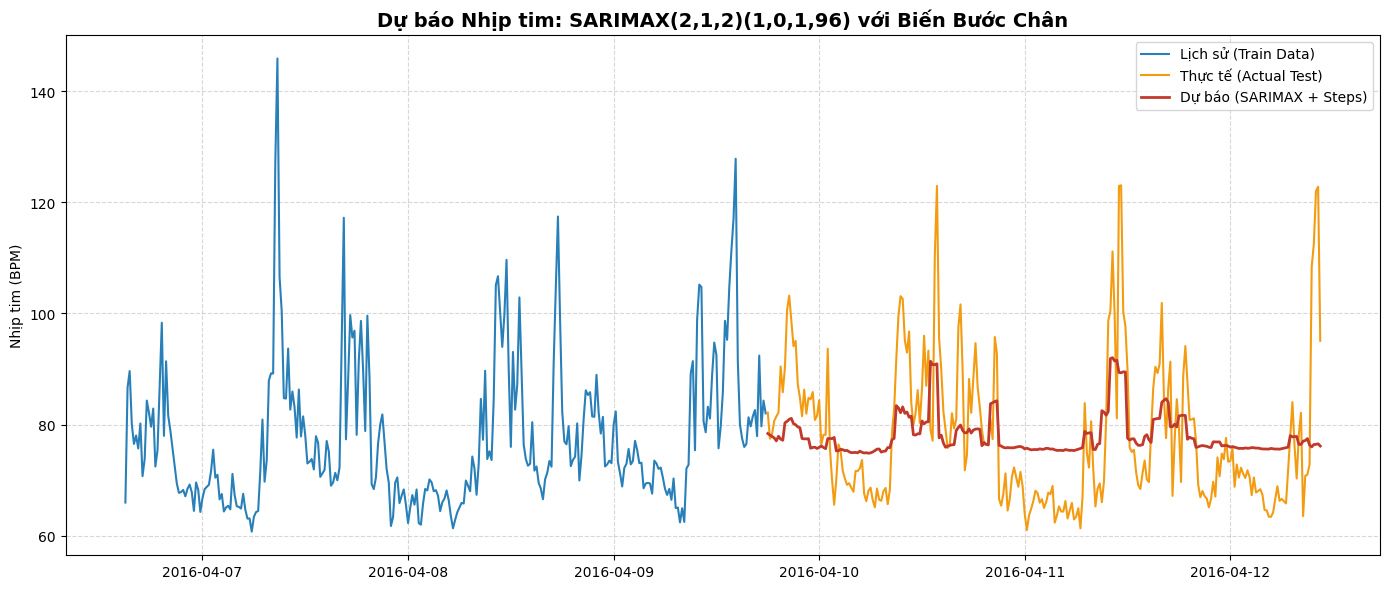

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error, mean_absolute_error

# 1. LOAD & CHỌN DỮ LIỆU
df = pd.read_csv('data.csv')
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
user_id = 6962181067
df_user = df[df['Id'] == user_id].sort_values('Timestamp').set_index('Timestamp')

# 2. TIỀN XỬ LÝ (RESAMPLE 15 PHÚT CHUẨN XÁC)
# Nhịp tim/Cường độ lấy trung bình. Bước chân/Calo lấy tổng.
df_15m = df_user.resample('15min').agg({
    'Heart_Rate': 'mean',
    'Intensity': 'mean',
    'Steps': 'sum',       
    'Calories': 'sum'     
}).interpolate() # Lấp đầy khoảng trống nếu có

# 3. CHIA TẬP TRAIN / TEST (80/20)
train_size = int(len(df_15m) * 0.8)
train = df_15m.iloc[:train_size]
test = df_15m.iloc[train_size:]

# Tách biến mục tiêu (y) và biến ngoại sinh (X)
train_y = train['Heart_Rate']
train_X = train[['Steps']]
test_y = test['Heart_Rate']
test_X = test[['Steps']]

# 4. HUẤN LUYỆN MÔ HÌNH SARIMAX
print("Đang huấn luyện SARIMAX với dữ liệu đã chuẩn hóa (Cần 1-3 phút)...")
# S = 96 (Chu kỳ 1 ngày có 96 block 15-phút)
model = SARIMAX(
    endog=train_y, 
    exog=train_X, 
    order=(2, 1, 2), 
    seasonal_order=(1, 0, 1, 96), 
    enforce_stationarity=False,
    enforce_invertibility=False
)
fitted_model = model.fit(disp=False)

# 5. DỰ BÁO
print("Đang dự báo...")
predictions = fitted_model.predict(
    start=len(train), 
    end=len(train) + len(test) - 1, 
    exog=test_X, 
    dynamic=False
)
predictions.index = test.index

# 6. ĐÁNH GIÁ & VẼ BIỂU ĐỒ
rmse = np.sqrt(mean_squared_error(test_y, predictions))
mae = mean_absolute_error(test_y, predictions)

print(f"\n--- ĐÁNH GIÁ ĐỘ CHÍNH XÁC ---")
print(f"RMSE: {rmse:.2f} bpm")
print(f"MAE:  {mae:.2f} bpm")
print("-" * 30)

plt.figure(figsize=(14, 6))
# Chỉ vẽ 300 điểm cuối của Train cho dễ nhìn
plt.plot(train.index[-300:], train_y.iloc[-300:], label='Lịch sử (Train Data)', color='#2980b9')
plt.plot(test.index, test_y, label='Thực tế (Actual Test)', color='#f39c12')
plt.plot(test.index, predictions, label='Dự báo (SARIMAX + Steps)', color='#c0392b', linewidth=2)

plt.title('Dự báo Nhịp tim: SARIMAX(2,1,2)(1,0,1,96) với Biến Bước Chân', fontsize=14, fontweight='bold')
plt.ylabel('Nhịp tim (BPM)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Đang huấn luyện SARIMAX với Steps, Calories, Intensity (Đợi 1-3 phút)...


/home/luongminhthu/Documents/code/university/FitBit-VitalSigns-Project/venv/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Đang dự báo...

--- KẾT QUẢ ĐÁNH GIÁ ---
RMSE: 9.95 bpm
MAE:  7.24 bpm
-------------------------


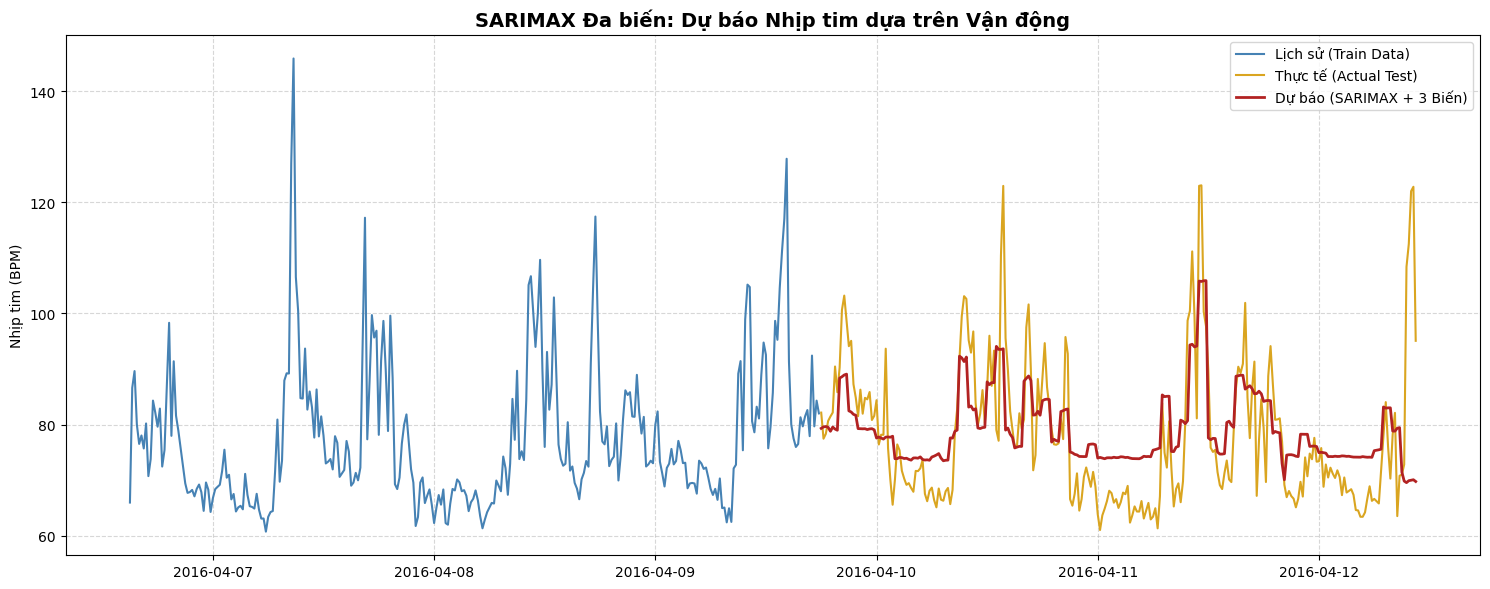

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error, mean_absolute_error

# 1. LOAD & CHỌN DỮ LIỆU
df = pd.read_csv('data.csv')
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
user_id = 6962181067
df_user = df[df['Id'] == user_id].sort_values('Timestamp').set_index('Timestamp')

# 2. TIỀN XỬ LÝ (RESAMPLE 15 PHÚT CHUẨN XÁC)
df_15m = df_user.resample('15min').agg({
    'Heart_Rate': 'mean',
    'Intensity': 'mean',  # Cường độ lấy trung bình
    'Steps': 'sum',       # Bước chân lấy tổng
    'Calories': 'sum'     # Calo lấy tổng
}).interpolate() # Lấp gap

# 3. CHIA TẬP TRAIN / TEST (80/20)
train_size = int(len(df_15m) * 0.8)
train = df_15m.iloc[:train_size]
test = df_15m.iloc[train_size:]

# Tách biến mục tiêu (y) và biến ngoại sinh (X) gồm 3 biến
features = ['Steps', 'Calories', 'Intensity']
train_y = train['Heart_Rate']
train_X = train[features]
test_y = test['Heart_Rate']
test_X = test[features]

# 4. HUẤN LUYỆN MÔ HÌNH SARIMAX (Full Biến Ngoại Sinh)
print("Đang huấn luyện SARIMAX với Steps, Calories, Intensity (Đợi 1-3 phút)...")
model = SARIMAX(
    endog=train_y, 
    exog=train_X, 
    order=(2, 1, 2), 
    seasonal_order=(1, 0, 1, 96), 
    enforce_stationarity=False,
    enforce_invertibility=False
)
fitted_model = model.fit(disp=False)

# 5. DỰ BÁO
print("Đang dự báo...")
predictions = fitted_model.predict(
    start=len(train), 
    end=len(train) + len(test) - 1, 
    exog=test_X, 
    dynamic=False
)
predictions.index = test.index

# 6. ĐÁNH GIÁ & VẼ BIỂU ĐỒ
rmse = np.sqrt(mean_squared_error(test_y, predictions))
mae = mean_absolute_error(test_y, predictions)

print(f"\n--- KẾT QUẢ ĐÁNH GIÁ ---")
print(f"RMSE: {rmse:.2f} bpm")
print(f"MAE:  {mae:.2f} bpm")
print("-" * 25)

plt.figure(figsize=(15, 6))
# Chỉ vẽ 300 điểm cuối của Train cho biểu đồ thoáng
plt.plot(train.index[-300:], train_y.iloc[-300:], label='Lịch sử (Train Data)', color='steelblue')
plt.plot(test.index, test_y, label='Thực tế (Actual Test)', color='goldenrod')
plt.plot(test.index, predictions, label='Dự báo (SARIMAX + 3 Biến)', color='firebrick', linewidth=2)

plt.title('SARIMAX Đa biến: Dự báo Nhịp tim dựa trên Vận động', fontsize=14, fontweight='bold')
plt.ylabel('Nhịp tim (BPM)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

I0000 00:00:1773578595.561262  456463 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1773578596.084043  456463 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1773578597.188353  456463 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


Đang huấn luyện mạng học sâu LSTM (Chạy 20 vòng, mất khoảng 1-2 phút)...


E0000 00:00:1773578597.593062  456463 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
/home/luongminhthu/Documents/code/university/FitBit-VitalSigns-Project/venv/lib/python3.13/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Đang dự báo...
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step

--- KẾT QUẢ LSTM ---
RMSE: 8.13 bpm
MAE:  5.11 bpm
-------------------------


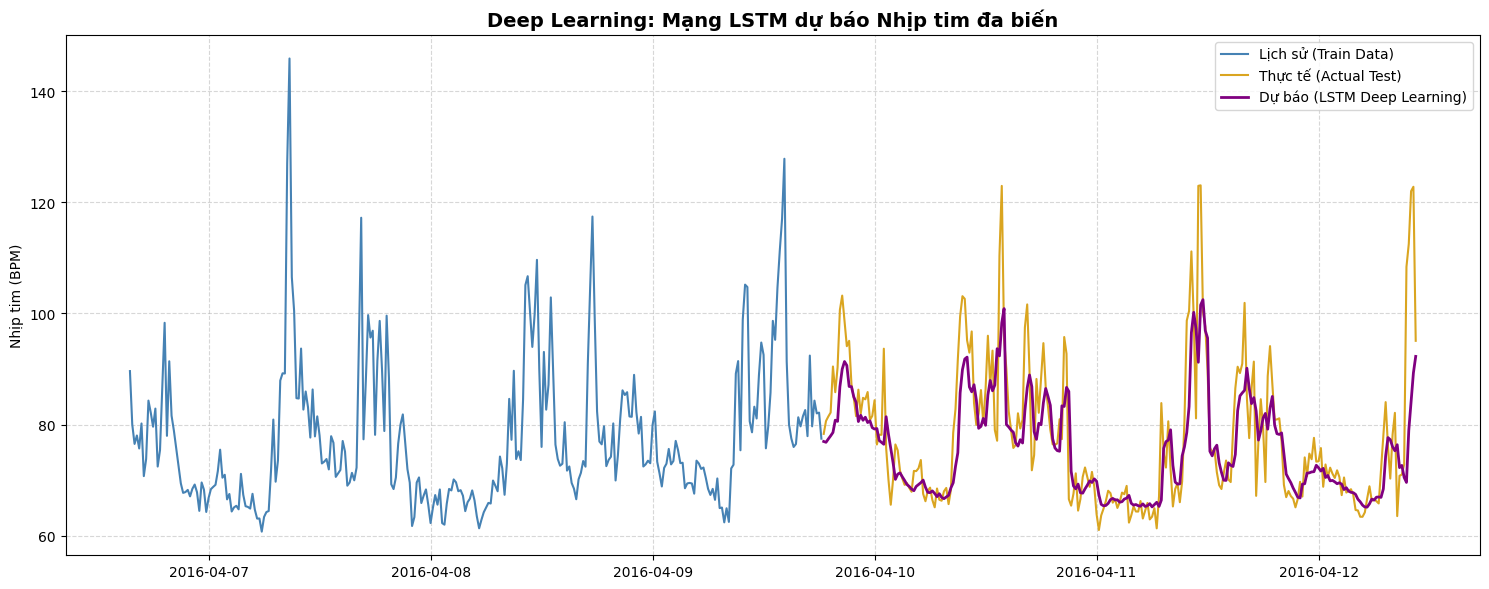

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.metrics import mean_squared_error, mean_absolute_error

# 1. LOAD & TIỀN XỬ LÝ (Như cũ)
df = pd.read_csv('data.csv')
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
user_id = 6962181067
df_user = df[df['Id'] == user_id].sort_values('Timestamp').set_index('Timestamp')

df_15m = df_user.resample('15min').agg({
    'Heart_Rate': 'mean', 'Intensity': 'mean',
    'Steps': 'sum', 'Calories': 'sum'     
}).interpolate()

# 2. CHUẨN HÓA DỮ LIỆU (Đưa về khoảng 0-1)
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df_15m)

# 3. TẠO CỬA SỔ QUÁ KHỨ (LOOK_BACK)
# Dùng 10 nhịp (2.5 tiếng) quá khứ để dự đoán tương lai
look_back = 10
X, y = [], []
for i in range(look_back, len(scaled_data)):
    X.append(scaled_data[i-look_back:i, :]) # Lấy quá khứ của cả 4 biến
    y.append(scaled_data[i, 0])             # Chỉ đoán Heart_Rate (cột 0) ở hiện tại
X, y = np.array(X), np.array(y)

# 4. CHIA TẬP TRAIN / TEST (80/20)
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# Lấy mốc thời gian cho tập Test để vẽ biểu đồ
test_dates = df_15m.index[look_back + train_size:]

# 5. XÂY DỰNG & HUẤN LUYỆN LSTM
print("Đang huấn luyện mạng học sâu LSTM (Chạy 20 vòng, mất khoảng 1-2 phút)...")
model = Sequential()
model.add(LSTM(50, activation='relu', input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(Dense(1)) # Đầu ra là 1 giá trị nhịp tim
model.compile(optimizer='adam', loss='mse')

# Bắt đầu học
model.fit(X_train, y_train, epochs=20, batch_size=32, verbose=0) 

# 6. DỰ BÁO & GIẢI CHUẨN HÓA (Đưa từ 0-1 về lại số Nhịp tim thật)
print("Đang dự báo...")
predictions_scaled = model.predict(X_test)

# Đảo ngược Scaling để lấy giá trị BPM
pred_descaled = np.zeros((len(predictions_scaled), 4))
pred_descaled[:, 0] = predictions_scaled[:, 0]
predictions_bpm = scaler.inverse_transform(pred_descaled)[:, 0]

y_test_descaled = np.zeros((len(y_test), 4))
y_test_descaled[:, 0] = y_test
actual_bpm = scaler.inverse_transform(y_test_descaled)[:, 0]

# 7. ĐÁNH GIÁ & VẼ BIỂU ĐỒ
rmse = np.sqrt(mean_squared_error(actual_bpm, predictions_bpm))
mae = mean_absolute_error(actual_bpm, predictions_bpm)

print(f"\n--- KẾT QUẢ LSTM ---")
print(f"RMSE: {rmse:.2f} bpm")
print(f"MAE:  {mae:.2f} bpm")
print("-" * 25)

plt.figure(figsize=(15, 6))
# Lấy một đoạn Train Data đã giải chuẩn hóa để vẽ cho đẹp
train_plot = scaler.inverse_transform(scaled_data[look_back:look_back+train_size])[:, 0]
train_dates = df_15m.index[look_back:look_back+train_size]

plt.plot(train_dates[-300:], train_plot[-300:], label='Lịch sử (Train Data)', color='steelblue')
plt.plot(test_dates, actual_bpm, label='Thực tế (Actual Test)', color='goldenrod')
plt.plot(test_dates, predictions_bpm, label='Dự báo (LSTM Deep Learning)', color='purple', linewidth=2)

plt.title('Deep Learning: Mạng LSTM dự báo Nhịp tim đa biến', fontsize=14, fontweight='bold')
plt.ylabel('Nhịp tim (BPM)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Đang huấn luyện LSTM Tối Ưu (Có Early Stopping)...


/home/luongminhthu/Documents/code/university/FitBit-VitalSigns-Project/venv/lib/python3.13/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Mô hình đã tự dừng ở vòng lặp thứ 41 để lấy kết quả tốt nhất!
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step  

--- KẾT QUẢ LSTM TỐI ƯU ---
RMSE: 8.37 bpm
MAE:  5.32 bpm
-------------------------


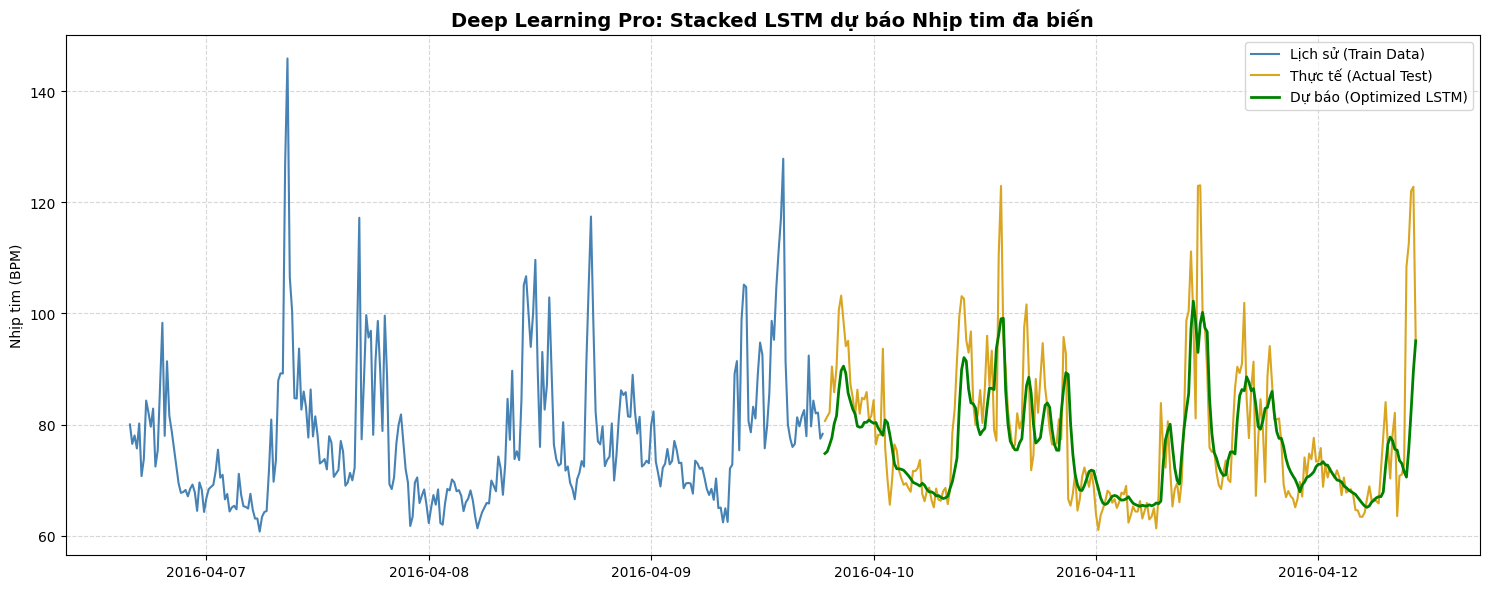

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_squared_error, mean_absolute_error

# 1. LOAD & TIỀN XỬ LÝ (Giữ nguyên)
df = pd.read_csv('data.csv')
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
user_id = 6962181067
df_user = df[df['Id'] == user_id].sort_values('Timestamp').set_index('Timestamp')

df_15m = df_user.resample('15min').agg({
    'Heart_Rate': 'mean', 'Intensity': 'mean',
    'Steps': 'sum', 'Calories': 'sum'     
}).interpolate()

# 2. CHUẨN HÓA DỮ LIỆU
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df_15m)

# 3. TẠO CỬA SỔ QUÁ KHỨ (Tăng lên 12 nhịp = 3 tiếng)
look_back = 12 
X, y = [], []
for i in range(look_back, len(scaled_data)):
    X.append(scaled_data[i-look_back:i, :]) 
    y.append(scaled_data[i, 0])             
X, y = np.array(X), np.array(y)

# 4. CHIA TẬP TRAIN / TEST (80/20)
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]
test_dates = df_15m.index[look_back + train_size:]

# 5. XÂY DỰNG & HUẤN LUYỆN LSTM TỐI ƯU (Cải tiến ở đây)
print("Đang huấn luyện LSTM Tối Ưu (Có Early Stopping)...")
model = Sequential()

# Lớp LSTM 1 + Dropout
model.add(LSTM(64, activation='relu', return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(Dropout(0.2)) # Tắt ngẫu nhiên 20% nơ-ron để chống Overfitting

# Lớp LSTM 2 + Dropout
model.add(LSTM(32, activation='relu'))
model.add(Dropout(0.2))

# Lớp Đầu ra
model.add(Dense(1))
model.compile(optimizer='adam', loss='mse')

# Cấu hình Early Stopping (Dừng nếu sau 10 vòng không tốt lên)
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Bắt đầu học (Trích 10% tập train làm bài kiểm tra phụ - validation)
history = model.fit(
    X_train, y_train, 
    epochs=100, 
    batch_size=32, 
    validation_split=0.1, 
    callbacks=[early_stop], 
    verbose=0
)

# 6. DỰ BÁO & GIẢI CHUẨN HÓA
print(f"Mô hình đã tự dừng ở vòng lặp thứ {len(history.epoch)} để lấy kết quả tốt nhất!")
predictions_scaled = model.predict(X_test)

pred_descaled = np.zeros((len(predictions_scaled), 4))
pred_descaled[:, 0] = predictions_scaled[:, 0]
predictions_bpm = scaler.inverse_transform(pred_descaled)[:, 0]

y_test_descaled = np.zeros((len(y_test), 4))
y_test_descaled[:, 0] = y_test
actual_bpm = scaler.inverse_transform(y_test_descaled)[:, 0]

# 7. ĐÁNH GIÁ & VẼ BIỂU ĐỒ
rmse = np.sqrt(mean_squared_error(actual_bpm, predictions_bpm))
mae = mean_absolute_error(actual_bpm, predictions_bpm)

print(f"\n--- KẾT QUẢ LSTM TỐI ƯU ---")
print(f"RMSE: {rmse:.2f} bpm")
print(f"MAE:  {mae:.2f} bpm")
print("-" * 25)

plt.figure(figsize=(15, 6))
train_plot = scaler.inverse_transform(scaled_data[look_back:look_back+train_size])[:, 0]
train_dates = df_15m.index[look_back:look_back+train_size]

plt.plot(train_dates[-300:], train_plot[-300:], label='Lịch sử (Train Data)', color='steelblue')
plt.plot(test_dates, actual_bpm, label='Thực tế (Actual Test)', color='goldenrod')
plt.plot(test_dates, predictions_bpm, label='Dự báo (Optimized LSTM)', color='green', linewidth=2) # Đổi sang màu xanh lá

plt.title('Deep Learning Pro: Stacked LSTM dự báo Nhịp tim đa biến', fontsize=14, fontweight='bold')
plt.ylabel('Nhịp tim (BPM)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Đang huấn luyện mô hình dự đoán đồng thời 4 biến...


/home/luongminhthu/Documents/code/university/FitBit-VitalSigns-Project/venv/lib/python3.13/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step  


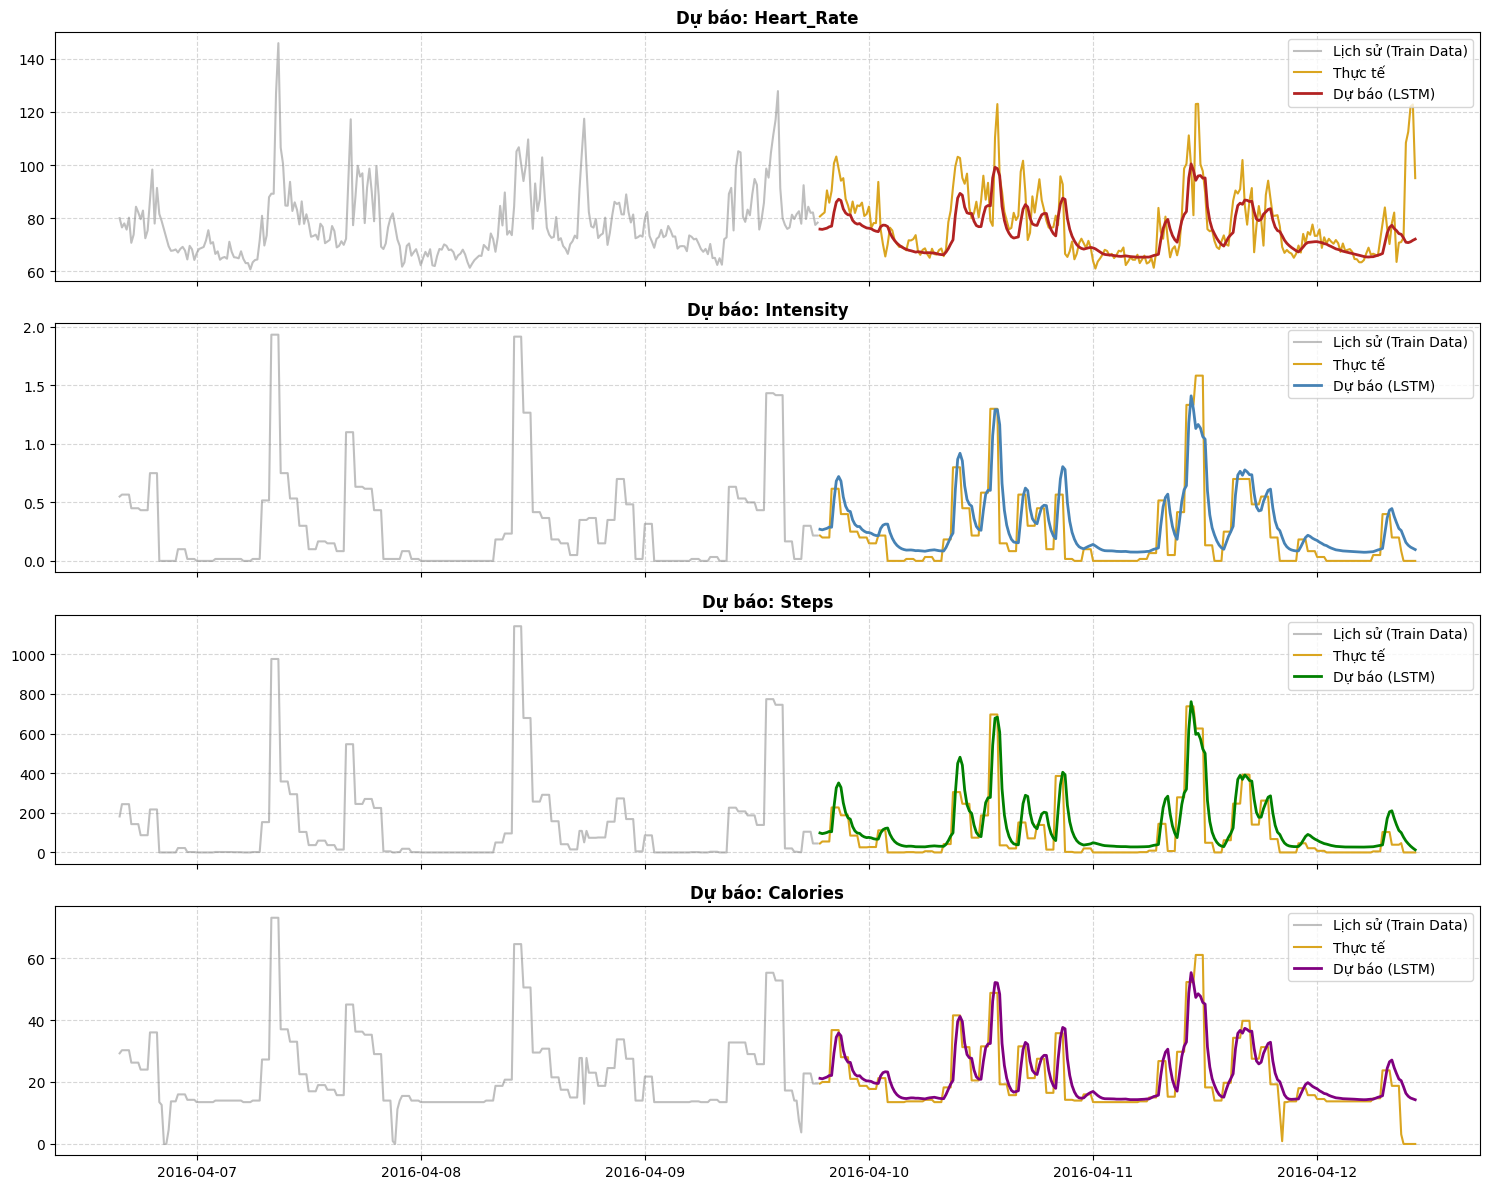

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# 1. TIỀN XỬ LÝ (GIỮ NGUYÊN)
df = pd.read_csv('data.csv')
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
user_id = 6962181067
df_user = df[df['Id'] == user_id].sort_values('Timestamp').set_index('Timestamp')

df_15m = df_user.resample('15min').agg({
    'Heart_Rate': 'mean', 'Intensity': 'mean',
    'Steps': 'sum', 'Calories': 'sum'     
}).interpolate()
features = ['Heart_Rate', 'Intensity', 'Steps', 'Calories']

# 2. CHUẨN HÓA DỮ LIỆU
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df_15m)

# 3. TẠO CỬA SỔ QUÁ KHỨ (12 Nhịp)
look_back = 12 
X, y = [], []
for i in range(look_back, len(scaled_data)):
    X.append(scaled_data[i-look_back:i, :]) # Lấy 4 biến ở 12 block quá khứ
    y.append(scaled_data[i, :])             # Lấy cả 4 biến ở hiện tại làm target
X, y = np.array(X), np.array(y)

# 4. CHIA TẬP TRAIN / TEST
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]
test_dates = df_15m.index[look_back + train_size:]

# 5. XÂY DỰNG MÔ HÌNH LSTM DỰ BÁO CÙNG LÚC 4 BIẾN
print("Đang huấn luyện mô hình dự đoán đồng thời 4 biến...")
model = Sequential()
model.add(LSTM(64, activation='relu', return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(Dropout(0.2))
model.add(LSTM(32, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(4)) # ĐIỂM KHÁC BIỆT CHÍNH: Đầu ra 4 nodes tương ứng 4 biến
model.compile(optimizer='adam', loss='mse')

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
history = model.fit(X_train, y_train, epochs=100, batch_size=32, validation_split=0.1, callbacks=[early_stop], verbose=0)

# 6. DỰ BÁO & GIẢI CHUẨN HÓA
predictions_scaled = model.predict(X_test)

# Đảo ngược Scaling để lấy lại giá trị thực của cả 4 biến
predictions_real = scaler.inverse_transform(predictions_scaled)
actual_real = scaler.inverse_transform(y_test)
train_plot = scaler.inverse_transform(scaled_data[look_back:look_back+train_size])
train_dates = df_15m.index[look_back:look_back+train_size]

# 7. VẼ HÌNH GỒM 4 BIỂU ĐỒ CON (Subplots)
fig, axes = plt.subplots(4, 1, figsize=(15, 12), sharex=True)
colors = ['firebrick', 'steelblue', 'green', 'purple']

for i, col in enumerate(features):
    axes[i].plot(train_dates[-300:], train_plot[-300:, i], label='Lịch sử (Train Data)', color='gray', alpha=0.5)
    axes[i].plot(test_dates, actual_real[:, i], label='Thực tế', color='goldenrod')
    axes[i].plot(test_dates, predictions_real[:, i], label='Dự báo (LSTM)', color=colors[i], linewidth=2)
    axes[i].set_title(f'Dự báo: {col}', fontsize=12, fontweight='bold')
    axes[i].legend(loc='upper right')
    axes[i].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()